# Regularized optimal transport

Optimal transport asks how to move mass from a source distribution to a target distribution with minimal total cost. In the discrete setting, the source marginal is $a \in \mathbb{R}^m_+$, the target marginal is $b \in \mathbb{R}^n_+$, and a transport plan is a nonnegative matrix $P \in \mathbb{R}^{m \times n}_+$ whose rows sum to $a$ and columns sum to $b$:

$$
P \mathbf{1}_n = a, \qquad P^\top \mathbf{1}_m = b.
$$

With cost matrix $C$, the unregularized problem is

$$
\min_{P \ge 0} \; \langle C, P \rangle
\quad \text{subject to} \quad
P \mathbf{1}_n = a, \; P^\top \mathbf{1}_m = b.
$$

This notebook uses the entropy-regularized version,

$$
\min_{P \ge 0}
\langle C, P \rangle
+ \varepsilon \sum_{i,j} P_{ij}(\log P_{ij} - 1)
\quad \text{subject to the same marginal constraints.}
$$

The main goal is not to introduce the fastest OT solver. It is to show how SpaceCore lets us write the mathematical objects once, then reuse the same problem definition across backends: NumPy for a reference Sinkhorn solve, and JAX/Optax for a differentiable dual optimization loop.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import optax

from spacecore.backend import Context, JaxOps, NumpyOps
from spacecore.space import DenseCoordinateSpace
from spacecore.linop import LinOp

## Encoding the mathematics once

The marginal constraints can be written as one linear equation

$$
A(P) = \begin{bmatrix} P \mathbf{1}_n \\ P^\top \mathbf{1}_m \end{bmatrix}
= \begin{bmatrix} a \\ b \end{bmatrix}.
$$

`MarginalLinOp` is this operator $A$. Its forward pass computes row and column sums. Its adjoint $A^*$ takes marginal dual variables and broadcasts them back to a matrix-shaped object, so each entry $(i, j)$ receives the source potential for row $i$ and the target potential for column $j$.

The regularized dual for a marginal dual vector $\lambda$ is

$$
\max_{\lambda} \;
\langle \lambda, [a, b] \rangle
- \varepsilon \sum_{i,j}
\exp\left(\frac{(A^*\lambda)_{ij} - C_{ij}}{\varepsilon}\right).
$$

That formula is why the problem class exposes both `dual_objective` and `plan_from_dual`. The optimizer only sees a vector of dual variables, while the transport plan is reconstructed through

$$
P(\lambda)_{ij}
= \exp\left(\frac{(A^*\lambda)_{ij} - C_{ij}}{\varepsilon}\right).
$$

Because the operator, arrays, and spaces all carry a `Context`, the same implementation can be converted from NumPy to JAX without rewriting these formulas.


In [2]:
class MarginalLinOp(LinOp):
    def __init__(self, plan_space, *, ctx=None):
        # The variable of the OT problem is a matrix P with shape (m, n).
        # Row i stores mass sent out of source bin i; column j stores mass
        # received by target bin j.
        m, n = plan_space.shape
        resolved_ctx = plan_space.ctx if ctx is None else ctx

        # A(P) contains all equality constraints in one vector:
        #     [row sums of P, column sums of P].
        marginal_space = DenseCoordinateSpace((m + n,), ctx=resolved_ctx)
        super().__init__(dom=plan_space, cod=marginal_space, ctx=resolved_ctx)
        self.m = m
        self.n = n

    def apply(self, plan):
        if self._enable_checks:
            self.dom.check_member(plan)

        # Forward map A(P): transport plan -> achieved marginals.
        row_sums = self.ops.sum(plan, axis=1)
        column_sums = self.ops.sum(plan, axis=0)
        return self.ops.concatenate([row_sums, column_sums])

    def rapply(self, marginal_dual):
        if self._enable_checks:
            self.cod.check_member(marginal_dual)

        # Adjoint map A^*(lambda): marginal potentials -> plan-shaped scores.
        # The first m entries price source constraints; the last n entries
        # price target constraints. Each transport entry P[i, j] sees both.
        row_dual = marginal_dual[:self.m]
        column_dual = marginal_dual[self.m:]
        return row_dual[:, None] + column_dual[None, :]

    def _convert(self, new_ctx):
        return MarginalLinOp(self.dom.convert(new_ctx), ctx=new_ctx)


class RegularizedOTProblem:
    def __init__(self, source, target, cost, epsilon, *, ctx):
        self.ctx = ctx
        self.ops = ctx.ops
        self.source = ctx.asarray(source)
        self.target = ctx.asarray(target)
        self.cost = ctx.asarray(cost)
        self.epsilon = epsilon
        self.m, self.n = self.cost.shape

        # Keep shape checks close to construction so later solver code can be
        # short and can assume the source, target, and cost are compatible.
        if self.source.shape != (self.m,):
            raise ValueError('source must match the number of cost rows')
        if self.target.shape != (self.n,):
            raise ValueError('target must match the number of cost columns')

        self.plan_space = DenseCoordinateSpace((self.m, self.n), ctx=ctx)
        self.marginal_op = MarginalLinOp(self.plan_space, ctx=ctx)
        self.marginal_target = self.ops.concatenate([self.source, self.target])

    def convert(self, new_ctx):
        return RegularizedOTProblem(
            new_ctx.asarray(self.source),
            new_ctx.asarray(self.target),
            new_ctx.asarray(self.cost),
            self.epsilon,
            ctx=new_ctx,
        )

    def primal_objective(self, plan):
        # Entropy-regularized primal objective:
        #     <C, P> + eps * sum(P * (log(P) - 1)).
        # The max only protects diagnostics from log(0); the optimized plans are
        # positive because they are exponentials of dual scores.
        positive_plan = self.ops.maximum(plan, 1e-300)
        transport_cost = self.ops.vdot(self.cost, plan)
        entropy = self.ops.sum(positive_plan * (self.ops.log(positive_plan) - 1.0))
        return transport_cost + self.epsilon * entropy

    def objective(self, plan):
        return self.primal_objective(plan)

    def marginal_error_norm(self, plan):
        # This is the feasibility residual ||A(P) - b||_2.
        error = self.marginal_op.apply(plan) - self.marginal_target
        return self.ops.sqrt(self.ops.sum(self.ops.abs(error) ** 2))

    def plan_from_dual(self, marginal_dual):
        # For entropy-regularized OT, maximizing over P for a fixed dual lambda
        # has the closed form P(lambda) = exp((A^* lambda - C) / epsilon).
        dual_on_plan = self.marginal_op.rapply(marginal_dual)
        logits = (dual_on_plan - self.cost) / self.epsilon
        return self.ops.exp(logits)

    def dual_objective(self, marginal_dual):
        # Dual objective:
        #     <lambda, b> - eps * sum(exp((A^* lambda - C) / eps)).
        # There is no extra normalization dual variable here; lambda already
        # contains the row and column marginal potentials.
        plan = self.plan_from_dual(marginal_dual)
        linear_term = self.ops.vdot(marginal_dual, self.marginal_target)
        conjugate_term = self.epsilon * self.ops.sum(plan)
        return linear_term - conjugate_term

    def negative_dual_objective(self, marginal_dual):
        # Optax minimizers expect a loss, so we minimize the negative dual.
        return -self.dual_objective(marginal_dual)


def gaussian_mixture_1d(ctx, grid, centers, scales, weights):
    ops = ctx.ops
    density = ops.zeros(grid.shape, dtype=ctx.dtype)
    for center, scale, weight in zip(centers, scales, weights):
        z = (grid - center) / scale
        density = density + weight * ops.exp(-0.5 * z * z)
    return density / ops.sum(density)


def squared_distance_cost(source_grid, target_grid):
    displacement = source_grid[:, None] - target_grid[None, :]
    return displacement * displacement


def to_numpy(array):
    return np.asarray(JaxOps.jax.device_get(array))


## A small discrete transport problem

We build two smooth one-dimensional probability distributions on grids of the same size. Keeping the source and target marginals the same length is not required by OT, but it removes shape distractions and keeps attention on the operator-based formulation.


In [3]:
np_ctx = Context(NumpyOps(), dtype='float64', enable_checks=True)
np_ops = np_ctx.ops

num_points = 48
source_grid = np_ops.arange(num_points, dtype=np_ctx.dtype) / (num_points - 1)
target_grid = np_ops.arange(num_points, dtype=np_ctx.dtype) / (num_points - 1)

source = gaussian_mixture_1d(
    np_ctx,
    source_grid,
    centers=(0.18, 0.48, 0.77),
    scales=(0.055, 0.075, 0.050),
    weights=(0.34, 0.42, 0.24),
)
target = gaussian_mixture_1d(
    np_ctx,
    target_grid,
    centers=(0.25, 0.62, 0.88),
    scales=(0.065, 0.055, 0.040),
    weights=(0.38, 0.36, 0.26),
)
cost = squared_distance_cost(source_grid, target_grid)
epsilon = 0.004

problem_np = RegularizedOTProblem(source, target, cost, epsilon, ctx=np_ctx)

print('source mass:', np_ops.sum(problem_np.source))
print('target mass:', np_ops.sum(problem_np.target))
print('plan shape:', problem_np.plan_space.shape)
print('marginal vector shape:', problem_np.marginal_op.cod.shape)


source mass: 1.0000000000000002
target mass: 0.9999999999999999
plan shape: (48, 48)
marginal vector shape: (96,)


## A NumPy reference solve

First we solve the regularized primal problem in the NumPy backend with Sinkhorn scaling. This gives a reliable reference transport plan and also checks that the data, cost, and marginal operator agree before moving to a different backend.


In [4]:
def solve_sinkhorn(problem, *, max_iter=20_000, tolerance=1e-12):
    ops = problem.ops
    kernel = ops.exp(-problem.cost / problem.epsilon)
    left = ops.ones((problem.m,), dtype=problem.ctx.dtype)
    right = ops.ones((problem.n,), dtype=problem.ctx.dtype)
    tiny = 1e-300

    for iteration in range(max_iter):
        # Alternating row and column rescaling enforces the two marginals.
        left = problem.source / ops.maximum(ops.matmul(kernel, right), tiny)
        right = problem.target / ops.maximum(ops.matmul(ops.transpose(kernel), left), tiny)

        if iteration % 100 == 0 or iteration == max_iter - 1:
            plan = left[:, None] * kernel * right[None, :]
            if float(problem.marginal_error_norm(plan)) < tolerance:
                return plan, iteration + 1

    return left[:, None] * kernel * right[None, :], max_iter


plan_np, sinkhorn_iterations = solve_sinkhorn(problem_np)

print('sinkhorn iterations:', sinkhorn_iterations)
print('numpy primal objective:', problem_np.objective(plan_np))
print('numpy marginal error:', problem_np.marginal_error_norm(plan_np))


sinkhorn iterations: 1001
numpy primal objective: -0.016892120788907505
numpy marginal error: 9.493478748528548e-14


## Reusing the same problem in JAX

Now the already-defined `RegularizedOTProblem` is converted to a JAX context. The mathematical object is the same: same source and target marginals, same cost, same marginal operator, and same dual objective. What changes is the backend that owns the arrays and executes the numerical work.

Optax minimizes the negative regularized dual. The Python loop stays explicit so the optimization is easy to read, but the update step is JIT-compiled: each compiled call evaluates the dual loss and gradient, applies the L-BFGS update, reconstructs the current plan, and returns scalar diagnostics.

The dual potentials have a constant-shift invariance between row and column potentials. We leave that invariance alone here; no extra normalization dual variable or penalty is needed for the notebook's purpose.


In [5]:
import jax
jax.config.update('jax_enable_x64', True)

# Checks are useful while constructing the NumPy problem above. For JIT-traced
# JAX values, Python-side membership checks can see tracers instead of concrete
# arrays, so the solver context disables them after the data has been validated.
jax_ctx = Context(JaxOps(), dtype='float64', enable_checks=False)
problem_jax = problem_np.convert(jax_ctx)


def solve_with_optax(problem, *, steps=1000, log_every=20):
    if problem.ops.family != 'jax':
        raise TypeError('Optax solve requires a JAX context.')

    optimizer = optax.lbfgs()
    potentials = problem.marginal_op.cod.zeros()
    opt_state = optimizer.init(potentials)

    def loss_fn(current_potentials):
        # Keep the loss as the negative dual so the mathematical objective stays
        # in RegularizedOTProblem and the optimizer code remains generic.
        return problem.negative_dual_objective(current_potentials)

    value_and_grad = optax.value_and_grad_from_state(loss_fn)

    @jax.jit
    def optax_step(current_potentials, current_opt_state):
        # This whole function is compiled: loss/grad, L-BFGS update, plan
        # reconstruction, and the scalar diagnostics used by the outer loop.
        loss, grads = value_and_grad(current_potentials, state=current_opt_state)
        updates, next_opt_state = optimizer.update(
            grads,
            current_opt_state,
            current_potentials,
            value=loss,
            grad=grads,
            value_fn=loss_fn,
        )
        next_potentials = optax.apply_updates(current_potentials, updates)

        # Diagnostics are computed from the updated potentials so the printed
        # values match the plan returned at the end of the solve.
        next_loss = loss_fn(next_potentials)
        plan = problem.plan_from_dual(next_potentials)
        primal = problem.objective(plan)
        marginal_error = problem.marginal_error_norm(plan)
        update_norm = problem.ops.sqrt(problem.ops.sum(problem.ops.abs(updates) ** 2))
        return next_potentials, next_opt_state, next_loss, primal, marginal_error, update_norm

    history = {
        'step': [],
        'negative_dual': [],
        'primal_objective': [],
        'marginal_error': [],
        'update_norm': [],
    }

    for step in range(1, steps + 1):
        potentials, opt_state, loss, primal, marginal_error, update_norm = optax_step(
            potentials,
            opt_state,
        )

        # Only transfer scalars back to NumPy when we want to print or plot.
        # Keeping all per-step arrays on device avoids unnecessary host traffic.
        if step == 1 or step % log_every == 0 or step == steps:
            history['step'].append(step)
            history['negative_dual'].append(float(to_numpy(loss)))
            history['primal_objective'].append(float(to_numpy(primal)))
            history['marginal_error'].append(float(to_numpy(marginal_error)))
            history['update_norm'].append(float(to_numpy(update_norm)))

            print(
                f'step {step:03d} | '
                f'negative dual {history["negative_dual"][-1]:.8e} | '
                f'primal {history["primal_objective"][-1]:.8e} | '
                f'marginal error {history["marginal_error"][-1]:.3e} | '
                f'update norm {history["update_norm"][-1]:.3e}'
            )

    plan = problem.plan_from_dual(potentials)
    return plan, potentials, history


plan_jax, potentials_jax, optax_history = solve_with_optax(problem_jax)

print('jax primal objective:', problem_jax.objective(plan_jax))
print('jax dual objective:', problem_jax.dual_objective(potentials_jax))
print('jax marginal error:', problem_jax.marginal_error_norm(plan_jax))


W0513 10:17:49.055857 5625411 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


step 001 | negative dual 2.09400055e-01 | primal -6.00152394e-15 | marginal error 2.709e-01 | update norm 1.000e+00
step 020 | negative dual 3.01528807e-02 | primal -1.20494339e-02 | marginal error 1.136e-01 | update norm 1.804e-02
step 040 | negative dual 1.91029940e-02 | primal -1.83400852e-02 | marginal error 4.261e-02 | update norm 1.237e-02
step 060 | negative dual 1.73691929e-02 | primal -1.70707765e-02 | marginal error 2.423e-02 | update norm 1.839e-02
step 080 | negative dual 1.70318398e-02 | primal -1.68139182e-02 | marginal error 9.192e-03 | update norm 5.196e-03
step 100 | negative dual 1.69648575e-02 | primal -1.68757775e-02 | marginal error 4.805e-03 | update norm 5.553e-03
step 120 | negative dual 1.69217542e-02 | primal -1.69530699e-02 | marginal error 1.525e-03 | update norm 5.679e-04
step 140 | negative dual 1.68981588e-02 | primal -1.69808451e-02 | marginal error 5.088e-03 | update norm 2.184e-03
step 160 | negative dual 1.68946428e-02 | primal -1.68763106e-02 | margi

## Reading the dual optimization

The Optax loop records a few scalar diagnostics while optimizing the dual. The marginal residual tells us how well the reconstructed plan satisfies $A(P) = [a, b]$. The negative-dual curve shows progress of the minimized objective, and the update norm shows how much the dual variables are still moving.

These plots are intentionally backend-level diagnostics: they confirm that the JAX version of the reusable problem object is behaving like the NumPy reference problem.


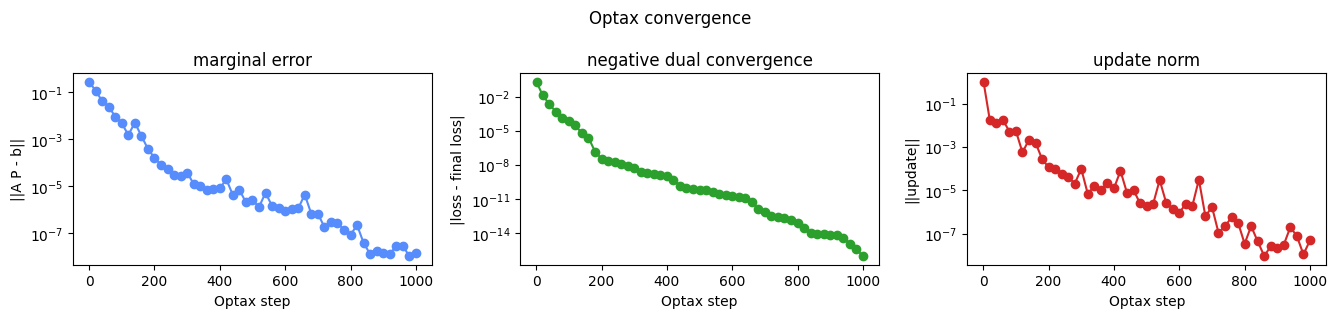

In [6]:
def plot_convergence(history):
    # The history was collected only at printed checkpoints, not every Optax
    # step. That keeps the loop readable while still showing the convergence trend.
    steps = np.asarray(history['step'])
    marginal_errors = np.asarray(history['marginal_error'])
    update_norms = np.asarray(history['update_norm']) + 1e-16
    negative_dual = np.asarray(history['negative_dual'])
    loss_distance = np.abs(negative_dual - negative_dual[-1]) + 1e-16

    fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.2))
    fig.suptitle('Optax convergence')
    axes[0].plot(steps, marginal_errors, marker='o')
    axes[0].set_title('marginal error')
    axes[0].set_xlabel('Optax step')
    axes[0].set_ylabel('||A P - b||')
    axes[0].set_yscale('log')

    axes[1].plot(steps, loss_distance, marker='o', color='tab:green')
    axes[1].set_title('negative dual convergence')
    axes[1].set_xlabel('Optax step')
    axes[1].set_ylabel('|loss - final loss|')
    axes[1].set_yscale('log')

    axes[2].plot(steps, update_norms, marker='o', color='tab:red')
    axes[2].set_title('update norm')
    axes[2].set_xlabel('Optax step')
    axes[2].set_ylabel('||update||')
    axes[2].set_yscale('log')

    fig.tight_layout()
    return fig

fig_convergence = plot_convergence(optax_history)
plt.show()

## Same model, different backend

The Sinkhorn plan and the Optax plan come from different algorithms, but they are solving the same regularized OT problem. This comparison is mainly a sanity check that the context conversion preserved the model rather than changing the mathematics.


In [7]:
plan_jax_np = to_numpy(plan_jax)
plan_np_array = to_numpy(plan_np)

plan_difference = plan_jax_np - plan_np_array
relative_difference = np.linalg.norm(plan_difference) / np.linalg.norm(plan_np_array)

print('numpy primal objective:', float(problem_np.objective(plan_np)))
print('jax primal objective:', float(to_numpy(problem_jax.objective(plan_jax))))
print('relative plan difference:', relative_difference)
print('max absolute plan difference:', np.max(np.abs(plan_difference)))


numpy primal objective: -0.016892120788907505
jax primal objective: -0.01689212084497003
relative plan difference: 8.133517128503489e-08
max absolute plan difference: 1.4051881429277824e-09


## Transport plans

The final heatmaps show the transport plans produced by the NumPy Sinkhorn solve and the JAX dual solve. Source locations index rows, target locations index columns, and brighter entries carry more transported mass.

The important point is that both plots come from the same `RegularizedOTProblem` definition. The backend changed; the mathematical model and the surrounding object structure did not.


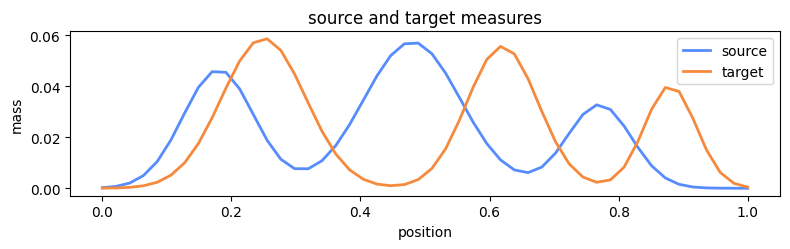

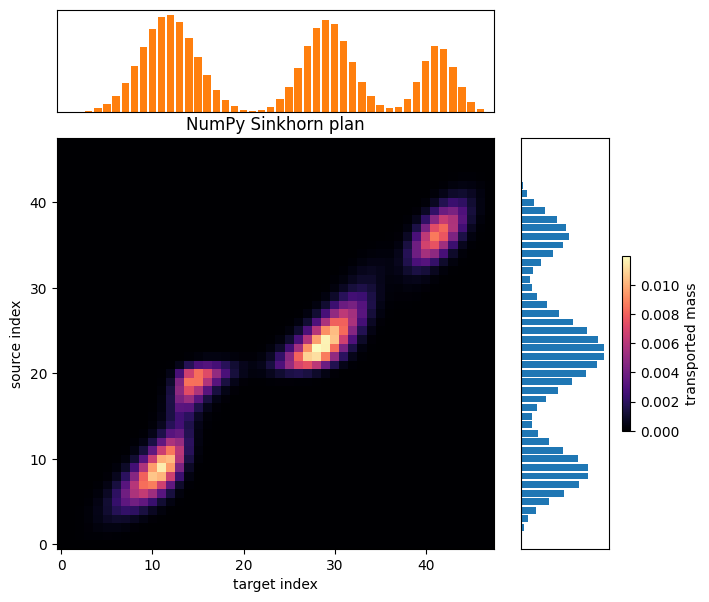

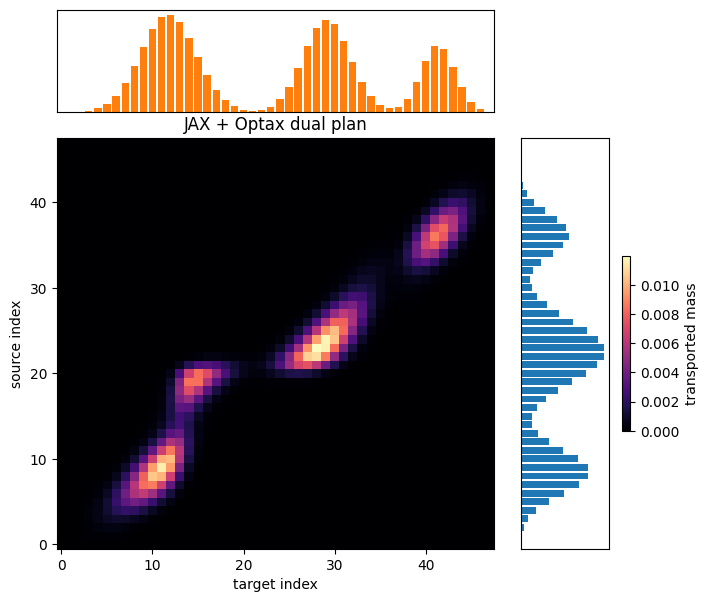

In [8]:
def plot_distributions(source_grid, source, target_grid, target):
    # Plot the two 1D measures before looking at the 2D transport matrix.
    fig, ax = plt.subplots(figsize=(8, 2.6))
    ax.plot(to_numpy(source_grid), to_numpy(source), label='source', linewidth=2)
    ax.plot(to_numpy(target_grid), to_numpy(target), label='target', linewidth=2)
    ax.set_title('source and target measures')
    ax.set_xlabel('position')
    ax.set_ylabel('mass')
    ax.legend()
    fig.tight_layout()
    return fig


def plot_transport_plan(plan, source, target, title):
    plan_array = to_numpy(plan)
    source_array = to_numpy(source)
    target_array = to_numpy(target)

    # The center heatmap is the plan. The top and right bars show the target
    # and source marginals so it is easy to read the plan against its constraints.
    fig = plt.figure(figsize=(7.4, 7.0))
    grid = fig.add_gridspec(
        2,
        2,
        width_ratios=(4.0, 1.0),
        height_ratios=(1.0, 4.0),
        hspace=0.1,
        wspace=0.1,
    )
    ax_top = fig.add_subplot(grid[0, 0])
    ax_plan = fig.add_subplot(grid[1, 0])
    ax_right = fig.add_subplot(grid[1, 1])

    image = ax_plan.imshow(plan_array, origin='lower', aspect='auto', cmap='magma')
    ax_plan.set_title(title)
    ax_plan.set_xlabel('target index')
    ax_plan.set_ylabel('source index')

    ax_top.bar(np.arange(target_array.size), target_array, color='tab:orange')
    ax_top.set_xlim(-0.5, target_array.size - 0.5)
    ax_top.set_xticks([])
    ax_top.set_yticks([])

    ax_right.barh(np.arange(source_array.size), source_array, color='tab:blue')
    ax_right.set_ylim(-0.5, source_array.size - 0.5)
    ax_right.set_xticks([])
    ax_right.set_yticks([])

    fig.colorbar(image, ax=ax_right, fraction=0.08, pad=0.12, label='transported mass')
    return fig


fig_distributions = plot_distributions(source_grid, problem_np.source, target_grid, problem_np.target)
fig_sinkhorn = plot_transport_plan(plan_np, problem_np.source, problem_np.target, 'NumPy Sinkhorn plan')
fig_optax = plot_transport_plan(plan_jax, problem_jax.source, problem_jax.target, 'JAX + Optax dual plan')
plt.show()